### NOTICE
#### Below code is just for ensuring the versions used by the SpaceDebrisRadar virtual enviornment.

In [1]:
import sys
import importlib

libs = ["pandas", "streamlit", "matplotlib", "seaborn", "sklearn", 'numpy', 'sklearn', 'scipy']

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print("-" * 70)

for lib in libs:
    try:
        module = importlib.import_module(lib)
        print(f"{lib} version: {module.__version__}")
        print(f"{lib} path: {module.__file__}")
    except ModuleNotFoundError:
        print(f"{lib} is NOT installed in this environment.")
    print("-" * 70)


Python executable: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\python.exe
Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
----------------------------------------------------------------------
pandas version: 2.3.3
pandas path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\pandas\__init__.py
----------------------------------------------------------------------
streamlit version: 1.48.0
streamlit path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\streamlit\__init__.py
----------------------------------------------------------------------
matplotlib version: 3.10.0
matplotlib path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\matplotlib\__init__.py
----------------------------------------------------------------------
seaborn version: 0.13.2
seaborn path: c:\Users\sushr\anaconda3\envs\SpaceDebrisRadar\Lib\site-packages\seaborn\__init__.py
---------------------------

In [2]:
# IMPORT HERE!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [3]:
#df = pd.read_csv('https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv', low_memory=False)
df = pd.read_csv('../data/01_raw/gp.csv')

### 📑 Useful Columns for SpaceDebrisRadar.AI

| Column Name     | Description                           | Usage in Project (ML/Logic) |
|-----------------|---------------------------------------|------------------------------|
| NORAD_CAT_ID    | Unique satellite identifier           | Tracking & referencing       |
| OBJECT_NAME     | Satellite/system name                 | System-based queries (e.g., Starlink) |
| MEAN_MOTION     | Revolutions per day (orbit speed)     | Clustering (KMeans), anomaly trends |
| INCLINATION     | Orbital tilt in degrees               | Clustering (shell grouping)  |
| ECCENTRICITY    | Orbit shape (circular vs. elliptical) | Orbit stability, anomaly detection |
| BSTAR           | Drag coefficient proxy                | Anomaly detection (decay risk) |
| EPOCH           | Timestamp of orbital elements         | Time-series, forecasting     |

----
### 🔎 About OBJECT_ID (A, B, C parts)

- `OBJECT_ID` format → `YYYY-NNNP`  
  - `YYYY` → Launch year  
  - `NNN` → Launch number in that year  
  - `P` → Piece (A, B, C, …)

- `A` → Primary payload (main satellite)  
- `B, C, …` → Secondary payloads, rocket bodies, or debris  
- Each part is a **separate object** in orbit (they do not join back).  
- Useful for anomaly detection → older `B/C` objects are often unstable or decaying.


In [24]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,U,900,999,4390,0.000815,8.060000e-06,0.0
1,CALSPHERE 2,1964-063E,2025-11-29 03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,U,902,999,82921,0.000042,3.700000e-07,0.0
2,LCS 1,1965-034C,2025-11-29 03:13:57.846720,9.893094,0.001341,32.1435,292.0260,134.3505,225.8092,0,U,1361,999,19007,0.000093,9.000000e-08,0.0
3,TEMPSAT 1,1965-065E,2025-11-29 03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,U,1512,999,93338,0.000091,5.500000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-11-29 04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,U,1520,999,93599,0.000265,1.470000e-06,0.0


In [5]:
df.shape

(13499, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13499 entries, 0 to 13498
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          13499 non-null  object 
 1   OBJECT_ID            13499 non-null  object 
 2   EPOCH                13499 non-null  object 
 3   MEAN_MOTION          13499 non-null  float64
 4   ECCENTRICITY         13499 non-null  float64
 5   INCLINATION          13499 non-null  float64
 6   RA_OF_ASC_NODE       13499 non-null  float64
 7   ARG_OF_PERICENTER    13499 non-null  float64
 8   MEAN_ANOMALY         13499 non-null  float64
 9   EPHEMERIS_TYPE       13499 non-null  int64  
 10  CLASSIFICATION_TYPE  13499 non-null  object 
 11  NORAD_CAT_ID         13499 non-null  int64  
 12  ELEMENT_SET_NO       13499 non-null  int64  
 13  REV_AT_EPOCH         13499 non-null  int64  
 14  BSTAR                13499 non-null  float64
 15  MEAN_MOTION_DOT      13499 non-null 

In [7]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
count,13499.000000,1.349900e+04,13499.000000,13499.000000,13499.000000,13499.000000,13499.0,13499.000000,13499.0,13499.000000,13499.000000,1.349900e+04,1.349900e+04
mean,14.206774,2.783141e-03,59.302967,172.112072,165.080170,197.094098,0.0,56111.310171,999.0,12965.399511,0.000020,-1.470043e-05,8.850133e-07
std,3.284316,3.935356e-02,23.704417,107.632366,94.035826,94.671060,0.0,8479.212938,0.0,13137.164230,0.005385,2.217281e-03,3.260747e-05
min,0.283528,3.000000e-07,0.001700,0.002600,0.044700,0.005500,0.0,900.000000,999.0,2.000000,-0.212100,-3.018033e-02,-2.053900e-07
25%,14.983428,1.236000e-04,43.003800,72.027550,87.933750,93.276800,0.0,51992.500000,999.0,3794.000000,0.000019,5.500000e-07,0.000000e+00
50%,15.088398,1.552000e-04,53.159900,169.069200,108.445800,253.180300,0.0,58017.000000,999.0,9990.000000,0.000119,1.161000e-05,0.000000e+00
75%,15.301919,2.982500e-04,81.001000,267.800150,267.455950,272.624200,0.0,62829.500000,999.0,18108.500000,0.000596,1.453350e-04,0.000000e+00
max,16.302461,8.742722e-01,147.693900,359.999800,359.963500,359.990800,0.0,66664.000000,999.0,99986.000000,0.098168,4.427753e-02,2.722200e-03


In [8]:
df['OBJECT_NAME']

0         CALSPHERE 1
1         CALSPHERE 2
2               LCS 1
3           TEMPSAT 1
4        CALSPHERE 4A
             ...     
13494       2025-274K
13495       2025-274L
13496       2025-274M
13497       2025-274N
13498     SOYUZ-MS 28
Name: OBJECT_NAME, Length: 13499, dtype: object

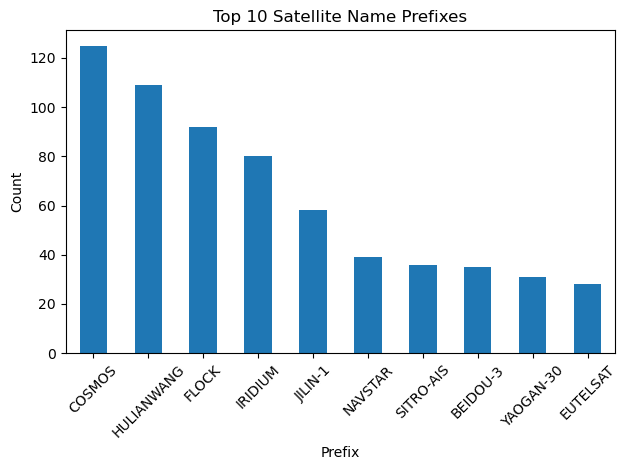

In [9]:
df['OBJECT_NAME'].str.split().str[0].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Satellite Name Prefixes')
plt.xlabel('Prefix')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()



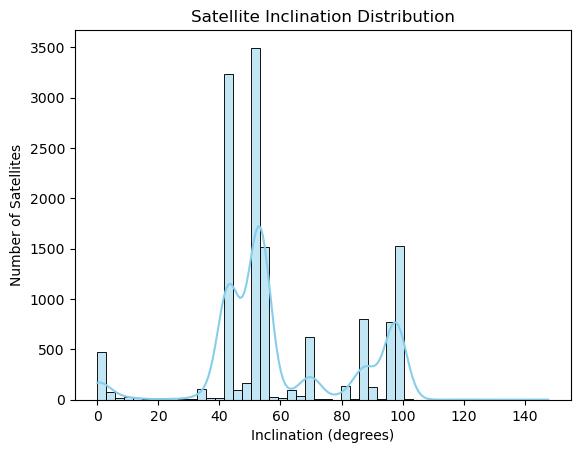

In [10]:
sns.histplot(data=df, x = 'INCLINATION', bins=50, color='skyblue', kde = True)

plt.title('Satellite Inclination Distribution')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Number of Satellites')
plt.show()


(0.0, 0.05)

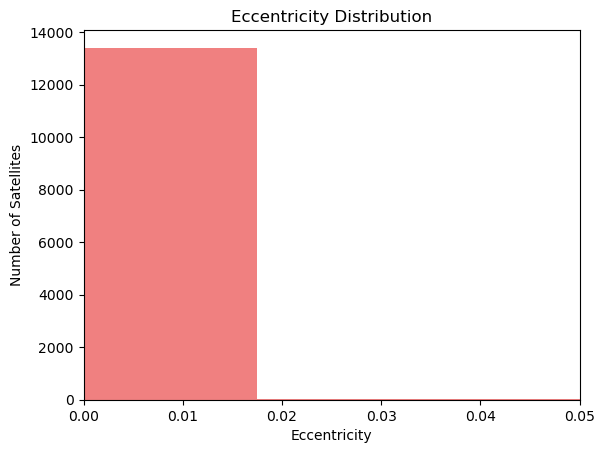

In [11]:
df['ECCENTRICITY'].plot(kind='hist', bins=50, color='lightcoral')
plt.title('Eccentricity Distribution')
plt.xlabel('Eccentricity')
plt.ylabel('Number of Satellites')

plt.xlim(0, 0.05)

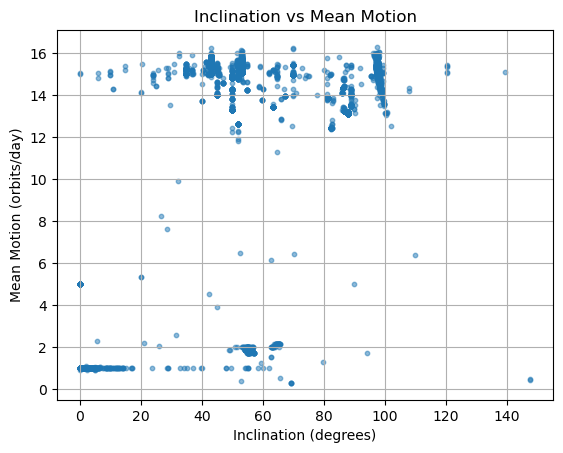

In [12]:
plt.scatter(df['INCLINATION'], df['MEAN_MOTION'], alpha=0.5, s=10)
plt.title('Inclination vs Mean Motion')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Mean Motion (orbits/day)')
plt.grid(True)
plt.show()


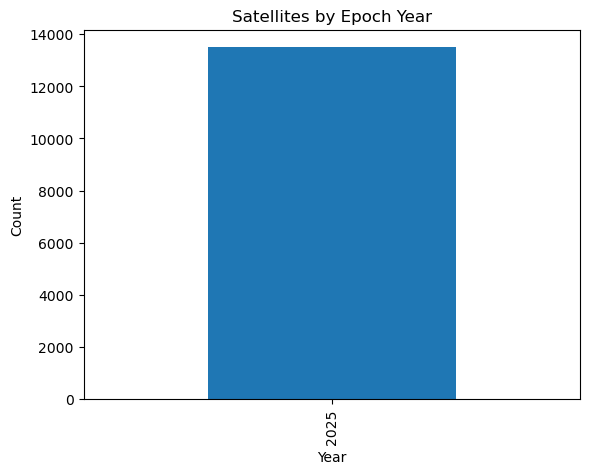

In [13]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'], errors='coerce')
df['EPOCH'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Satellites by Epoch Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


In [14]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
13494,2025-274K,2025-274K,2025-11-29 04:47:55.198752,14.926825,0.001295,97.7370,260.6425,329.8933,30.1541,0,U,66659,999,38,0.000311,0.000032,0.0
13495,2025-274L,2025-274L,2025-11-29 04:47:33.582336,14.928316,0.001357,97.7370,260.6431,330.1871,29.8574,0,U,66660,999,38,0.000363,0.000037,0.0
13496,2025-274M,2025-274M,2025-11-29 04:47:10.516992,14.929880,0.001422,97.7370,260.6434,330.9976,29.0452,0,U,66661,999,38,0.000253,0.000026,0.0
13497,2025-274N,2025-274N,2025-11-29 04:46:59.883744,14.930582,0.001461,97.7378,260.6434,330.6795,29.3604,0,U,66662,999,38,0.000158,0.000016,0.0
13498,SOYUZ-MS 28,2025-275A,2025-11-28 22:21:16.003872,15.491774,0.000374,51.6312,210.8341,180.7008,179.3975,0,U,66664,999,30,0.000178,0.000094,0.0


In [15]:
df[df['OBJECT_NAME'].str.contains('STARLINK')]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
1360,STARLINK-1008,2019-074B,2025-11-29 02:57:11.342880,15.064047,0.000163,53.0545,278.0775,93.7947,266.3229,0,U,44714,999,33359,0.000202,0.000027,0.000000
1361,STARLINK-1011,2019-074E,2025-11-29 01:22:58.505376,16.101571,0.000246,53.0428,242.4420,163.0875,197.0241,0,U,44717,999,33408,0.000767,0.007468,0.000315
1362,STARLINK-1012,2019-074F,2025-11-29 02:25:20.400384,15.063941,0.000187,53.0530,278.1772,85.7071,274.4132,0,U,44718,999,33358,0.000045,0.000004,0.000000
1363,STARLINK-1017,2019-074L,2025-11-29 03:46:06.993696,15.171427,0.000543,53.0500,272.5839,52.1806,307.9679,0,U,44723,999,33367,0.001222,0.000243,0.000000
1364,STARLINK-1019,2019-074M,2025-11-29 04:27:21.510432,15.541858,0.000352,53.0534,270.9842,99.2068,260.9340,0,U,44724,999,33369,0.001840,0.001234,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13475,STARLINK-35744,2025-268AA,2025-11-29 04:00:01.998720,15.889609,0.000180,42.9976,202.2709,269.1987,324.7216,0,U,66581,999,244,-0.005983,-0.015563,0.000000
13476,STARLINK-35746,2025-268AB,2025-11-29 04:00:01.998720,15.890069,0.000182,42.9974,202.2651,269.9288,326.2554,0,U,66582,999,248,-0.006031,-0.015705,0.000000
13477,STARLINK-35941,2025-268AC,2025-11-29 04:00:01.998720,15.890497,0.000172,42.9973,202.2597,265.8755,332.3681,0,U,66583,999,248,-0.006046,-0.015770,0.000000
13478,STARLINK-35939,2025-268AD,2025-11-29 04:00:01.998720,15.890851,0.000187,42.9978,202.2558,268.2525,331.7665,0,U,66584,999,248,-0.005997,-0.015682,0.000000


Text(0.5, 0, 'Mean Motion')

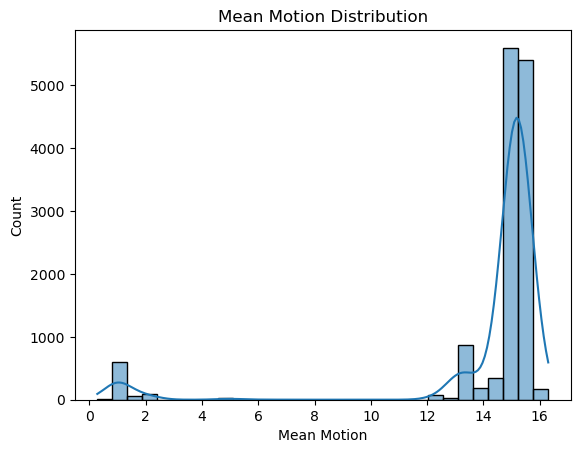

In [16]:
sns.histplot(data=df, x = 'MEAN_MOTION', bins = 30, kde=True)

plt.title('Mean Motion Distribution')
plt.xlabel('Mean Motion')


In [17]:
df['BSTAR'].value_counts()

BSTAR
 0.000000    791
 0.000170      8
 0.000180      5
 0.001447      3
 0.000045      3
            ... 
-0.005983      1
-0.006031      1
-0.006046      1
-0.005997      1
 0.000122      1
Name: count, Length: 12363, dtype: int64

(-0.2, 0.2)

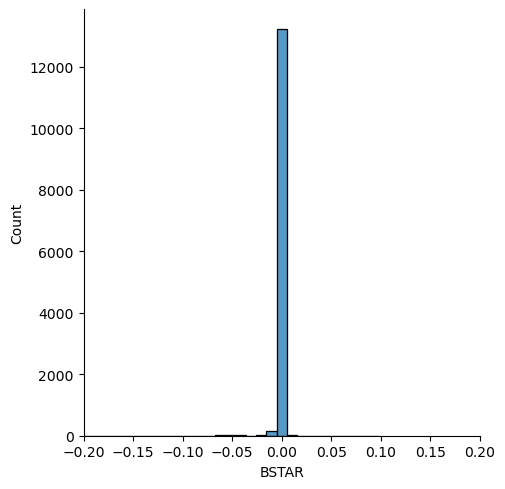

In [18]:
sns.displot(data=df, x = 'BSTAR', bins = 30)

plt.xlim(-0.2, 0.2)
#plt.ylim(-0.1, 2)

Text(0.5, 0, 'Revolutions')

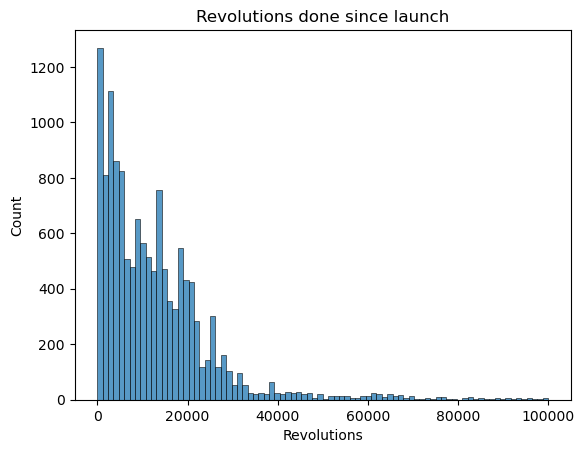

In [19]:
sns.histplot(data=df, x = 'REV_AT_EPOCH')

plt.title('Revolutions done since launch')
plt.xlabel('Revolutions')

In [20]:
# Compare total orbits done and the launch year distribution
launch_years = df['OBJECT_ID'].str.strip().str.split('-').str[0]

In [21]:
launch_years

0        1964
1        1964
2        1965
3        1965
4        1965
         ... 
13494    2025
13495    2025
13496    2025
13497    2025
13498    2025
Name: OBJECT_ID, Length: 13499, dtype: object

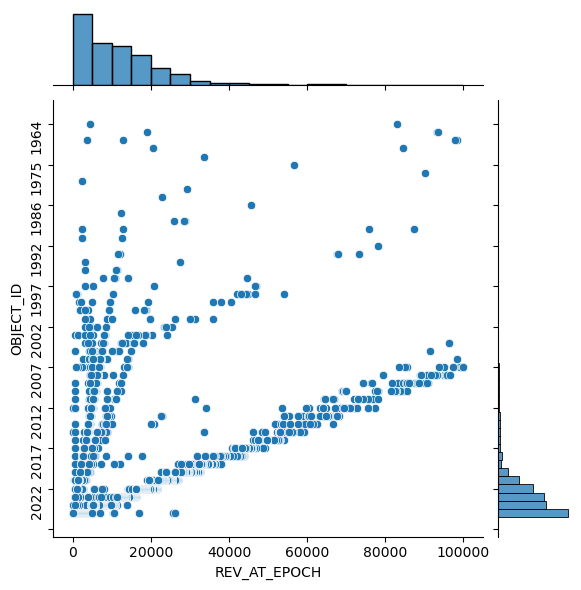

In [22]:
import matplotlib.ticker as ticker
g = sns.jointplot(data=df, x='REV_AT_EPOCH', y=launch_years, kind='scatter', marginal_kws=dict(bins=20, orientation="vertical"))

# Set a major tick for every 5 years on the y-axis
g.ax_joint.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.ax_joint.tick_params(axis='y', rotation=90)

plt.show()